[1/7] Building dataset …
      Total samples : 201
      Label counts  :
label
positive    101
negative    100

[2/7] Preprocessing text …
      Train: 160  |  Test: 41

[3/7] Training baseline models …

  BASELINE MODEL RESULTS  (no tuning)

── Logistic Regression
   Accuracy : 92.68%
   Train time: 0.006s

── LinearSVC
   Accuracy : 92.68%
   Train time: 0.005s

── Naive Bayes
   Accuracy : 92.68%
   Train time: 0.005s

[4/7] Running GridSearchCV …

  GRIDSEARCHCV  (exhaustive search)

   Best Parameters : {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
   CV Best Score   : 83.12%
   Test Accuracy   : 95.12%
   Search Time     : 0.86s
   Combinations tried: 24

[5/7] Running RandomizedSearchCV …

  RANDOMIZEDSEARCHCV  (efficient random search)

   Best Parameters : {'tfidf__ngram_range': (1, 3), 'tfidf__max_features': 2000, 'clf__solver': 'liblinear', 'clf__penalty': 'l2', 'clf__C': 0.1}
   CV Best Score   : 

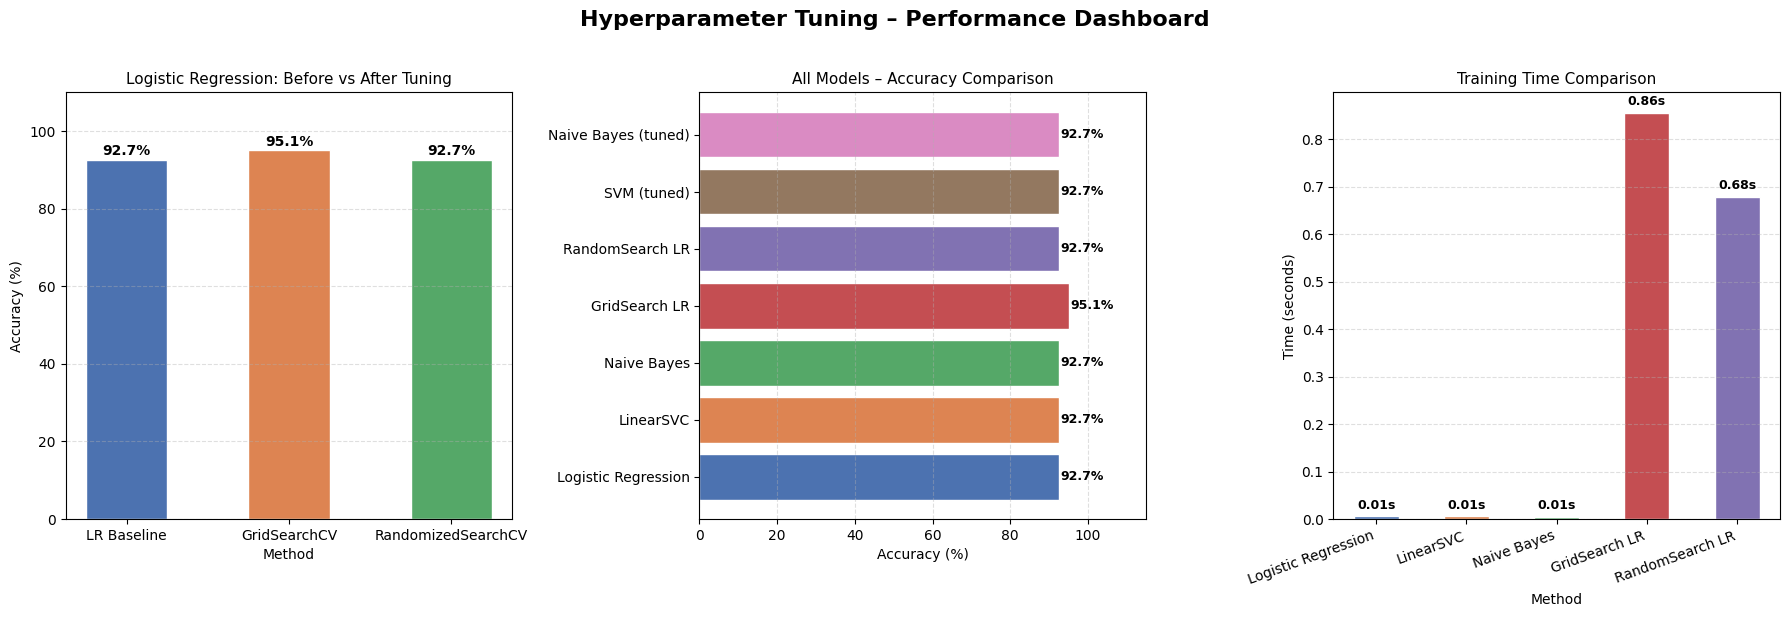

[✓] Confusion matrix saved as  confusion_matrix.png


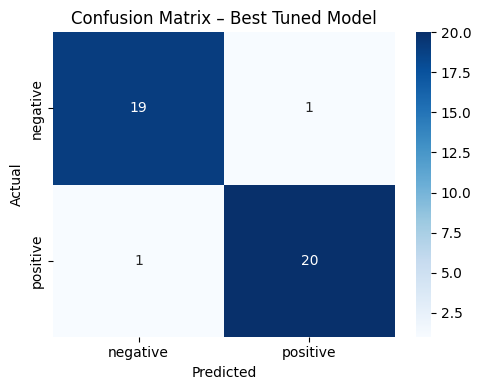


── Detailed Classification Report (Best Tuned Model):
              precision    recall  f1-score   support

    negative       0.95      0.95      0.95        20
    positive       0.95      0.95      0.95        21

    accuracy                           0.95        41
   macro avg       0.95      0.95      0.95        41
weighted avg       0.95      0.95      0.95        41

[✓] Best model saved as  best_model.pkl

  PREDICTION SYSTEM  (type 'quit' to exit)

  Enter text: I am a good girl

  Prediction (Tuned Model): POSITIVE
  Confidence              : 87.8%

  Enter text: quit
  Exiting prediction system.


In [2]:

import warnings
warnings.filterwarnings("ignore")

import re
import time
import string
import joblib
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn            as sns

import nltk
nltk.download("stopwords",    quiet=True)
nltk.download("wordnet",      quiet=True)
nltk.download("punkt",        quiet=True)
nltk.download("punkt_tab",    quiet=True)
nltk.download("omw-1.4",      quiet=True)

from nltk.corpus              import stopwords
from nltk.stem                import WordNetLemmatizer

from sklearn.model_selection  import (train_test_split,
                                      GridSearchCV,
                                      RandomizedSearchCV,
                                      cross_val_score)
from sklearn.pipeline         import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import LinearSVC
from sklearn.naive_bayes      import MultinomialNB
from sklearn.metrics          import (accuracy_score,
                                      classification_report,
                                      confusion_matrix)


# ─────────────────────────────────────────────
# 1.  DATASET
# ─────────────────────────────────────────────
def build_dataset() -> pd.DataFrame:
    """Return a small but balanced sentiment dataset."""
    positive = [
        "I absolutely loved this product, it works perfectly!",
        "Amazing quality, fast delivery, very happy with my purchase.",
        "Great service, the staff was friendly and helpful.",
        "This is the best thing I have bought all year.",
        "Fantastic experience, highly recommend to everyone.",
        "The product exceeded my expectations, truly excellent.",
        "Outstanding performance, worth every penny.",
        "I am so satisfied with this purchase, will buy again.",
        "Superb quality and very durable.",
        "Wonderful experience from start to finish.",
        "The customer support was incredibly responsive and kind.",
        "Brilliant product, exactly as described.",
        "Very pleased with the results, five stars!",
        "Top-notch quality, I am impressed.",
        "Excellent value for money, very happy customer.",
        "Loved every bit of it, packaging was also great.",
        "Highly recommended! Will definitely order again.",
        "Best purchase decision I have made recently.",
        "The item arrived quickly and in perfect condition.",
        "I could not be happier with this product.",
        "Such a great deal, quality is amazing.",
        "Really happy with how it works, totally worth it.",
        "Impressive product, very sturdy and well-made.",
        "Thrilled with this purchase, exceeded all expectations.",
        "Great buy! Will tell all my friends about this.",
        "Very satisfied, shipping was faster than expected.",
        "Absolutely delighted with the quality and service.",
        "Phenomenal product, works exactly as advertised.",
        "I love this item, it makes my life so much easier.",
        "100% recommend, perfect in every way.",
        "Delivery was quick and the product is fantastic.",
        "So happy with this! Great value for the price.",
        "Everything was perfect from order to delivery.",
        "Nice product, feels premium and well crafted.",
        "Very good quality, will definitely buy again.",
        "Loved the packaging and the product itself is great.",
        "Awesome product, I use it every single day.",
        "Really impressed, better than I expected.",
        "Smooth experience, the app is very intuitive.",
        "Brilliant, responsive, and affordable – highly recommend.",
        "An excellent product that truly delivers results.",
        "I have been using it for a month now, still great.",
        "Fast and reliable, exactly what I needed.",
        "Very innovative design, so easy to use.",
        "Five stars! Nothing to complain about.",
        "The best customer service I have experienced.",
        "Works like a charm, very pleased.",
        "Incredible quality for the price, buy it now.",
        "Very positive experience overall, thank you!",
        "Absolutely love it, can not imagine life without it.",
        # more positive samples
        "This exceeded every expectation I had.",
        "Perfect product, beautiful packaging, fast shipping.",
        "I highly recommend this to anyone who needs it.",
        "Such a smooth and enjoyable experience.",
        "The quality is top tier, beyond satisfied.",
        "Truly remarkable product, will order more.",
        "Exactly what I needed, very efficient.",
        "Very pleasant experience, great customer service.",
        "I am blown away by how good this is.",
        "Definitely a five-star product and service.",
        "This product has improved my daily routine.",
        "Good quality material, sturdy and reliable.",
        "Best decision I made this month, love it.",
        "Clean design, works perfectly, highly rated.",
        "Quick delivery and product is top quality.",
        "Super happy with this, totally recommended.",
        "Smooth transaction, perfect product.",
        "This brand never disappoints, excellent again.",
        "Very easy to set up and use, great product.",
        "Well packaged and exactly as described.",
        "Flawless experience from purchase to delivery.",
        "Quality speaks for itself, amazing product.",
        "Totally worth the money, no regrets.",
        "Reliable, durable, and affordable – love it.",
        "I am thrilled with my purchase, 10/10.",
        "Everything worked as expected, very happy.",
        "Wonderful product, exceeded my expectations.",
        "Great aesthetics and fantastic functionality.",
        "Love the design and how easy it is to use.",
        "My family loves it too, great family product.",
        "Absolutely fantastic, buy it without hesitation.",
        "So glad I found this product, game changer.",
        "Perfect quality, super fast delivery.",
        "Just amazing, will be buying more soon.",
        "This is exactly what I was looking for.",
        "So simple yet so effective, brilliant.",
        "Really high quality, looks and feels premium.",
        "Very happy with everything about this product.",
        "Exactly as shown, great value for money.",
        "I have been recommending this to everyone I know.",
        "Could not ask for a better product at this price.",
        "Surpassed expectations on all fronts.",
        "An excellent addition to my collection.",
        "Remarkable quality, pleasantly surprised.",
        "Wonderful packaging and even better product.",
        "I ordered twice because I love it so much.",
        "The performance is unmatched, very impressive.",
        "Seamless ordering process and great product.",
        "Really glad I chose this, no disappointments.",
        "This product is everything I hoped for and more.",
        "Outstanding in every way, fully satisfied.",
    ]

    negative = [
        "Terrible product, broke after one day of use.",
        "Very disappointed, does not work as described.",
        "Awful quality, total waste of money.",
        "The item arrived damaged and customer support was useless.",
        "I regret buying this, worst purchase ever.",
        "Poor quality, fell apart within a week.",
        "Not worth the money at all, very disappointed.",
        "The product is completely different from the photos.",
        "Extremely bad experience, will never buy again.",
        "Horrible service, waited weeks and got the wrong item.",
        "Defective product, had to return immediately.",
        "Terrible customer service, no response to emails.",
        "Cheap and flimsy, broke on first use.",
        "Very unhappy with this purchase.",
        "Fraudulent listing, product is fake.",
        "Would not recommend to anyone, bad quality.",
        "Disappointed with the build quality, not durable.",
        "Waste of time and money, avoid this product.",
        "The product stopped working after a few uses.",
        "Nothing worked as advertised, very misleading.",
        "Poor packaging, item was scratched on arrival.",
        "Took forever to arrive and was completely broken.",
        "Not what I expected, very low quality.",
        "Absolutely horrible product, zero stars.",
        "Worst customer experience I have ever had.",
        "Product is useless, does not do what it claims.",
        "Extremely overpriced for such poor quality.",
        "I am furious, this is a scam.",
        "Never again, completely unreliable.",
        "Very bad, stopped working on the first day.",
        "The material is so cheap, I am disgusted.",
        "Misleading product description, very unhappy.",
        "Zero stars if I could, terrible experience.",
        "Bad smell, poor build, not as described.",
        "Returned it immediately, complete garbage.",
        "Very poor quality control, items missing.",
        "Absolutely not worth it, save your money.",
        "I have never been so let down by a purchase.",
        "Nothing positive to say, just avoid this.",
        "Instructions were wrong and product did not work.",
        "Do not buy this, it is a total rip-off.",
        "Very thin and fragile, broke within hours.",
        "Packaging was damaged and product was broken.",
        "Could not get it to work at all, useless.",
        "Spent a lot and got nothing useful.",
        "Horrible experience, no support at all.",
        "Wrong item sent, still waiting for refund.",
        "Quality is abysmal, not as described.",
        "Very disappointing, expected much better.",
        "Total scam, stay away from this product.",
        # more negative samples
        "Broke immediately after opening the box.",
        "False advertising, product looks nothing like photos.",
        "Extremely cheap material, very disappointed.",
        "The worst purchase of my life, avoid.",
        "Customer service was rude and unhelpful.",
        "Product does not function at all.",
        "Horrible smell and terrible build quality.",
        "Arrived two weeks late and was broken.",
        "Completely useless item, total waste.",
        "Very bad experience, no response from seller.",
        "Not durable at all, fell apart quickly.",
        "Would give zero stars if I could.",
        "The quality is insulting for the price asked.",
        "Defective out of the box, requested refund.",
        "Terrible instructions and the product failed.",
        "Nothing works as promised, avoid this brand.",
        "Never received my order, awful company.",
        "Product is a joke, not functional at all.",
        "Extremely disappointed, will not be back.",
        "Horrible quality control, broken on arrival.",
        "Scam! Nothing like the description.",
        "Worst value for money I have ever seen.",
        "Absolutely terrible, do not buy this.",
        "Very unhappy with everything about this order.",
        "I wish I had read the reviews first.",
        "Cheap knockoff, not the real product.",
        "Broken hinges, peeling paint, just awful.",
        "Do not waste your money on this garbage.",
        "Shoddy workmanship, embarrassingly bad.",
        "Took three weeks to arrive and was wrong item.",
        "Shocking quality, I demand a full refund.",
        "Nothing positive, just avoid this seller.",
        "Useless product, not worth a single cent.",
        "Very poor performance, way below expectations.",
        "I have had better free samples than this.",
        "Extremely bad quality, returned immediately.",
        "Product failed within 24 hours, disgusting.",
        "What a disaster, every part was broken.",
        "Overpriced garbage, absolute disappointment.",
        "Item was soaking wet when it arrived.",
        "Cannot believe they sell this junk.",
        "The listing is completely dishonest.",
        "Regret every penny spent on this.",
        "This is the worst product I have ever seen.",
        "Not even close to the advertised quality.",
        "Falling apart already, terrible build.",
        "Extremely bad, broken from day one.",
        "No quality assurance whatsoever.",
        "Lost my money and got a broken product.",
        "Never buying from this brand again, ever.",
    ]

    texts  = positive + negative
    labels = ["positive"] * len(positive) + ["negative"] * len(negative)
    df     = pd.DataFrame({"text": texts, "label": labels})
    return df.sample(frac=1, random_state=42).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. TEXT PREPROCESSING
# ─────────────────────────────────────────────
lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words("english"))

def preprocess(text: str) -> str:
    """Lowercase → remove punctuation/numbers → remove stopwords → lemmatize."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)        # remove punctuation & digits
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return " ".join(tokens)


# ─────────────────────────────────────────────
# 3. PIPELINE BUILDER
# ─────────────────────────────────────────────
def make_pipeline(model) -> Pipeline:
    """TF-IDF vectorizer + classifier pipeline."""
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2),
            sublinear_tf=True
        )),
        ("clf", model)
    ])


# ─────────────────────────────────────────────
# 4. BASELINE MODELS
# ─────────────────────────────────────────────
def train_baseline(X_train, y_train, X_test, y_test):
    """Train Logistic Regression, SVM, Naive Bayes without tuning."""
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "LinearSVC"          : LinearSVC(max_iter=2000, random_state=42),
        "Naive Bayes"        : MultinomialNB(),
    }

    baseline_results = {}
    print("\n" + "="*60)
    print("  BASELINE MODEL RESULTS  (no tuning)")
    print("="*60)

    for name, clf in models.items():
        pipe   = make_pipeline(clf)
        t0     = time.time()
        pipe.fit(X_train, y_train)
        elapsed = time.time() - t0

        acc = accuracy_score(y_test, pipe.predict(X_test))
        baseline_results[name] = {"accuracy": acc, "time": elapsed, "model": pipe}

        print(f"\n── {name}")
        print(f"   Accuracy : {acc*100:.2f}%")
        print(f"   Train time: {elapsed:.3f}s")

    return baseline_results


# ─────────────────────────────────────────────
# 5. HYPERPARAMETER TUNING
# ─────────────────────────────────────────────
def grid_search_tuning(X_train, y_train, X_test, y_test):
    """GridSearchCV on Logistic Regression pipeline."""
    print("\n" + "="*60)
    print("  GRIDSEARCHCV  (exhaustive search)")
    print("="*60)

    pipe = make_pipeline(LogisticRegression(max_iter=2000, random_state=42))

    param_grid = {
        "tfidf__max_features": [3000, 5000],
        "tfidf__ngram_range" : [(1, 1), (1, 2)],
        "clf__C"             : [0.1, 1, 10],
        "clf__solver"        : ["liblinear", "lbfgs"],
        "clf__penalty"       : ["l2"],        # lbfgs only supports l2
    }

    t0   = time.time()
    grid = GridSearchCV(pipe, param_grid, cv=5,
                        scoring="accuracy", n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)
    elapsed = time.time() - t0

    best_acc = accuracy_score(y_test, grid.predict(X_test))

    print(f"\n   Best Parameters : {grid.best_params_}")
    print(f"   CV Best Score   : {grid.best_score_*100:.2f}%")
    print(f"   Test Accuracy   : {best_acc*100:.2f}%")
    print(f"   Search Time     : {elapsed:.2f}s")
    print(f"   Combinations tried: {len(grid.cv_results_['params'])}")

    return grid, best_acc, elapsed


def random_search_tuning(X_train, y_train, X_test, y_test):
    """RandomizedSearchCV on Logistic Regression pipeline."""
    print("\n" + "="*60)
    print("  RANDOMIZEDSEARCHCV  (efficient random search)")
    print("="*60)

    pipe = make_pipeline(LogisticRegression(max_iter=2000, random_state=42))

    param_dist = {
        "tfidf__max_features": [2000, 3000, 5000, 7000],
        "tfidf__ngram_range" : [(1, 1), (1, 2), (1, 3)],
        "clf__C"             : [0.01, 0.1, 1, 10, 100],
        "clf__penalty"       : ["l2"],
        "clf__solver"        : ["liblinear", "lbfgs"],
    }

    t0  = time.time()
    rnd = RandomizedSearchCV(pipe, param_dist, n_iter=20, cv=5,
                             scoring="accuracy", n_jobs=-1,
                             random_state=42, verbose=0)
    rnd.fit(X_train, y_train)
    elapsed = time.time() - t0

    best_acc = accuracy_score(y_test, rnd.predict(X_test))

    print(f"\n   Best Parameters : {rnd.best_params_}")
    print(f"   CV Best Score   : {rnd.best_score_*100:.2f}%")
    print(f"   Test Accuracy   : {best_acc*100:.2f}%")
    print(f"   Search Time     : {elapsed:.2f}s")
    print(f"   Iterations tried: 20 (random)")

    return rnd, best_acc, elapsed


# ─────────────────────────────────────────────
# 6. MULTI-MODEL TUNING
# ─────────────────────────────────────────────
def tune_multiple_models(X_train, y_train, X_test, y_test):
    """Tune SVM and Naive Bayes as well."""
    print("\n" + "="*60)
    print("  BONUS: MULTI-MODEL TUNING")
    print("="*60)

    results = {}

    # ── SVM
    svm_pipe   = make_pipeline(LinearSVC(max_iter=3000, random_state=42))
    svm_params = {
        "tfidf__max_features": [3000, 5000],
        "clf__C"             : [0.1, 1, 10],
    }
    svm_grid = GridSearchCV(svm_pipe, svm_params, cv=5,
                            scoring="accuracy", n_jobs=-1)
    t0 = time.time()
    svm_grid.fit(X_train, y_train)
    svm_time = time.time() - t0
    svm_acc  = accuracy_score(y_test, svm_grid.predict(X_test))
    results["SVM (tuned)"] = {"accuracy": svm_acc, "time": svm_time}
    print(f"\n   SVM  → Best Params: {svm_grid.best_params_}"
          f"  |  Test Acc: {svm_acc*100:.2f}%  |  Time: {svm_time:.2f}s")

    # ── Naive Bayes
    nb_pipe   = make_pipeline(MultinomialNB())
    nb_params = {
        "tfidf__max_features": [3000, 5000],
        "clf__alpha"         : [0.1, 0.5, 1.0, 2.0],
    }
    nb_grid = GridSearchCV(nb_pipe, nb_params, cv=5,
                           scoring="accuracy", n_jobs=-1)
    t0 = time.time()
    nb_grid.fit(X_train, y_train)
    nb_time = time.time() - t0
    nb_acc  = accuracy_score(y_test, nb_grid.predict(X_test))
    results["Naive Bayes (tuned)"] = {"accuracy": nb_acc, "time": nb_time}
    print(f"   NB   → Best Params: {nb_grid.best_params_}"
          f"  |  Test Acc: {nb_acc*100:.2f}%  |  Time: {nb_time:.2f}s")

    return results


# ─────────────────────────────────────────────
# 7. VISUALISATION
# ─────────────────────────────────────────────
def plot_results(baseline_results, grid_acc, rnd_acc, multi_results):
    """Generate and save comparison plots."""

    # ── Colour palette
    palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
               "#8172B2", "#937860", "#DA8BC3"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Hyperparameter Tuning – Performance Dashboard",
                 fontsize=16, fontweight="bold", y=1.02)

    # ── Plot 1: Baseline vs Tuned (LR)
    ax = axes[0]
    lr_baseline = baseline_results["Logistic Regression"]["accuracy"] * 100
    labels  = ["LR Baseline", "GridSearchCV", "RandomizedSearchCV"]
    values  = [lr_baseline, grid_acc * 100, rnd_acc * 100]
    colors  = [palette[0], palette[1], palette[2]]
    bars    = ax.bar(labels, values, color=colors, width=0.5, edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontweight="bold")
    ax.set_ylim(0, 110)
    ax.set_title("Logistic Regression: Before vs After Tuning", fontsize=11)
    ax.set_ylabel("Accuracy (%)")
    ax.set_xlabel("Method")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # ── Plot 2: All model accuracies
    ax = axes[1]
    all_names = (list(baseline_results.keys()) +
                 ["GridSearch LR", "RandomSearch LR"] +
                 list(multi_results.keys()))
    all_accs  = ([v["accuracy"] * 100 for v in baseline_results.values()] +
                 [grid_acc * 100, rnd_acc * 100] +
                 [v["accuracy"] * 100 for v in multi_results.values()])
    bar_colors = [palette[i % len(palette)] for i in range(len(all_names))]
    bars = ax.barh(all_names, all_accs, color=bar_colors, edgecolor="white")
    for bar, val in zip(bars, all_accs):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va="center", fontweight="bold", fontsize=9)
    ax.set_xlim(0, 115)
    ax.set_title("All Models – Accuracy Comparison", fontsize=11)
    ax.set_xlabel("Accuracy (%)")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    # ── Plot 3: Training time comparison
    ax = axes[2]
    time_names = list(baseline_results.keys()) + ["GridSearch LR", "RandomSearch LR"]
    time_vals  = ([v["time"] for v in baseline_results.values()] +
                  [grid_time, rnd_time])
    colors_t = [palette[i % len(palette)] for i in range(len(time_names))]
    bars = ax.bar(time_names, time_vals, color=colors_t,
                  width=0.5, edgecolor="white")
    for bar, val in zip(bars, time_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}s", ha="center", va="bottom", fontweight="bold", fontsize=9)
    ax.set_title("Training Time Comparison", fontsize=11)
    ax.set_ylabel("Time (seconds)")
    ax.set_xlabel("Method")
    ax.set_xticklabels(time_names, rotation=20, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig("tuning_results.png", dpi=150, bbox_inches="tight")
    print("\n[✓] Plot saved as  tuning_results.png")
    plt.show()


# ─────────────────────────────────────────────
# 8. CONFUSION MATRIX PLOT
# ─────────────────────────────────────────────
def plot_confusion(best_model, X_test, y_test):
    y_pred = best_model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    labels = best_model.classes_ if hasattr(best_model, "classes_") else ["negative", "positive"]

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title("Confusion Matrix – Best Tuned Model")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    print("[✓] Confusion matrix saved as  confusion_matrix.png")
    plt.show()


# ─────────────────────────────────────────────
# 9. SAVE BEST MODEL
# ─────────────────────────────────────────────
def save_model(grid_search_obj, filename="best_model.pkl"):
    joblib.dump(grid_search_obj.best_estimator_, filename)
    print(f"[✓] Best model saved as  {filename}")


# ─────────────────────────────────────────────
# 10. PREDICTION SYSTEM
# ─────────────────────────────────────────────
def predict_interactive(model):
    print("\n" + "="*60)
    print("  PREDICTION SYSTEM  (type 'quit' to exit)")
    print("="*60)
    while True:
        text = input("\n  Enter text: ").strip()
        if text.lower() in ("quit", "exit", "q"):
            print("  Exiting prediction system.")
            break
        if not text:
            continue
        cleaned   = preprocess(text)
        prediction = model.predict([cleaned])[0]
        try:
            proba = model.predict_proba([cleaned])[0]
            conf  = max(proba) * 100
            print(f"\n  Prediction (Tuned Model): {prediction.upper()}")
            print(f"  Confidence              : {conf:.1f}%")
        except AttributeError:
            print(f"\n  Prediction (Tuned Model): {prediction.upper()}")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":

    # ── Build dataset
    print("[1/7] Building dataset …")
    df = build_dataset()
    print(f"      Total samples : {len(df)}")
    print(f"      Label counts  :\n{df['label'].value_counts().to_string()}")

    # ── Preprocess
    print("\n[2/7] Preprocessing text …")
    df["clean_text"] = df["text"].apply(preprocess)

    # ── Split
    X_train, X_test, y_train, y_test = train_test_split(
        df["clean_text"], df["label"],
        test_size=0.2, random_state=42, stratify=df["label"]
    )
    print(f"      Train: {len(X_train)}  |  Test: {len(X_test)}")

    # ── Baseline
    print("\n[3/7] Training baseline models …")
    baseline_results = train_baseline(X_train, y_train, X_test, y_test)

    # ── GridSearchCV
    print("\n[4/7] Running GridSearchCV …")
    grid_model, grid_acc, grid_time = grid_search_tuning(X_train, y_train, X_test, y_test)

    # ── RandomizedSearchCV
    print("\n[5/7] Running RandomizedSearchCV …")
    rnd_model, rnd_acc, rnd_time = random_search_tuning(X_train, y_train, X_test, y_test)

    # ── Multi-model tuning (bonus)
    print("\n[6/7] Tuning multiple models (SVM, Naive Bayes) …")
    multi_results = tune_multiple_models(X_train, y_train, X_test, y_test)

    # ── Summary table
    lr_base = baseline_results["Logistic Regression"]["accuracy"] * 100
    print("\n" + "="*60)
    print("  PERFORMANCE COMPARISON SUMMARY")
    print("="*60)
    print(f"  {'Model':<30} {'Accuracy':>10}")
    print(f"  {'-'*42}")
    for name, info in baseline_results.items():
        print(f"  {name + ' (baseline)':<30} {info['accuracy']*100:>9.2f}%")
    print(f"  {'GridSearchCV – LR (tuned)':<30} {grid_acc*100:>9.2f}%")
    print(f"  {'RandomizedSearchCV – LR (tuned)':<30} {rnd_acc*100:>9.2f}%")
    for name, info in multi_results.items():
        print(f"  {name:<30} {info['accuracy']*100:>9.2f}%")

    print(f"\n  Before Tuning Accuracy (LR) : {lr_base:.2f}%")
    print(f"  After  Tuning Accuracy (LR) : {max(grid_acc, rnd_acc)*100:.2f}%")
    print(f"  Improvement                  : +{(max(grid_acc, rnd_acc)*100 - lr_base):.2f}%")

    # ── Plots
    print("\n[7/7] Generating plots …")
    plot_results(baseline_results, grid_acc, rnd_acc, multi_results)

    # ── Confusion matrix for best tuned model
    best_model = (grid_model.best_estimator_
                  if grid_acc >= rnd_acc
                  else rnd_model.best_estimator_)
    plot_confusion(best_model, X_test, y_test)

    # ── Classification report
    print("\n── Detailed Classification Report (Best Tuned Model):")
    y_pred = best_model.predict(X_test)
    print(classification_report(y_test, y_pred))

    # ── Save best model
    save_model(grid_model if grid_acc >= rnd_acc else rnd_model)

    # ── Interactive prediction
    predict_interactive(best_model)